<h1 style="color:white; background-color:teal; padding:10px; text-align:center;">
Customer Service Request Analysis
</h1>

<h2 style="color:white; background-color:#1f77b4; padding:8px;">
Task 1: Understand the Dataset
</h2>

# 1.1 Import Dataset

In [1]:
import pandas as pd
df = pd.read_csv("311_Service_Requests_from_2010_to_Present.csv")


C:\Users\test\AppData\Local\Temp\ipykernel_3504\310309575.py:2: DtypeWarning: Columns (48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("311_Service_Requests_from_2010_to_Present.csv")


# 1.2 View Data

In [2]:
df.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,12/31/2015 11:59:45 PM,01/01/2016 12:55:15 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,12/31/2015 11:59:44 PM,01/01/2016 01:26:57 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,12/31/2015 11:59:29 PM,01/01/2016 04:51:03 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"
3,32305098,12/31/2015 11:57:46 PM,01/01/2016 07:43:13 AM,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)"
4,32306529,12/31/2015 11:56:58 PM,01/01/2016 03:24:42 AM,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)"


# 1.3 Shape

In [3]:
df.shape

(364558, 53)

# 1.4 Columns

In [4]:
df.columns

Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip',
       'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2',
       'Intersection Street 1', 'Intersection Street 2', 'Address Type',
       'City', 'Landmark', 'Facility Type', 'Status', 'Due Date',
       'Resolution Description', 'Resolution Action Updated Date',
       'Community Board', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough',
       'School Name', 'School Number', 'School Region', 'School Code',
       'School Phone Number', 'School Address', 'School City', 'School State',
       'School Zip', 'School Not Found', 'School or Citywide Complaint',
       'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location',
       'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp',
       'Bridge Highway Segment', 'Garage Lot Name', 'Ferry 

# 1.5 Null Values

In [5]:
print(df.isnull().sum())

Unique Key                             0
Created Date                           0
Closed Date                         2381
Agency                                 0
Agency Name                            0
Complaint Type                         0
Descriptor                          6501
Location Type                        133
Incident Zip                        2998
Incident Address                   51699
Street Name                        51699
Cross Street 1                     57188
Cross Street 2                     57805
Intersection Street 1             313438
Intersection Street 2             314046
Address Type                        3252
City                                2997
Landmark                          364183
Facility Type                       2389
Status                                 0
Due Date                               3
Resolution Description                 0
Resolution Action Updated Date      2402
Community Board                        0
Borough         

<h2 style="color:white; background-color:#1f77b4; padding:8px;">
Task 2: Perform basic data exploratory analysis: 
</h2>

# 2.1 Remove records with null Closed Date

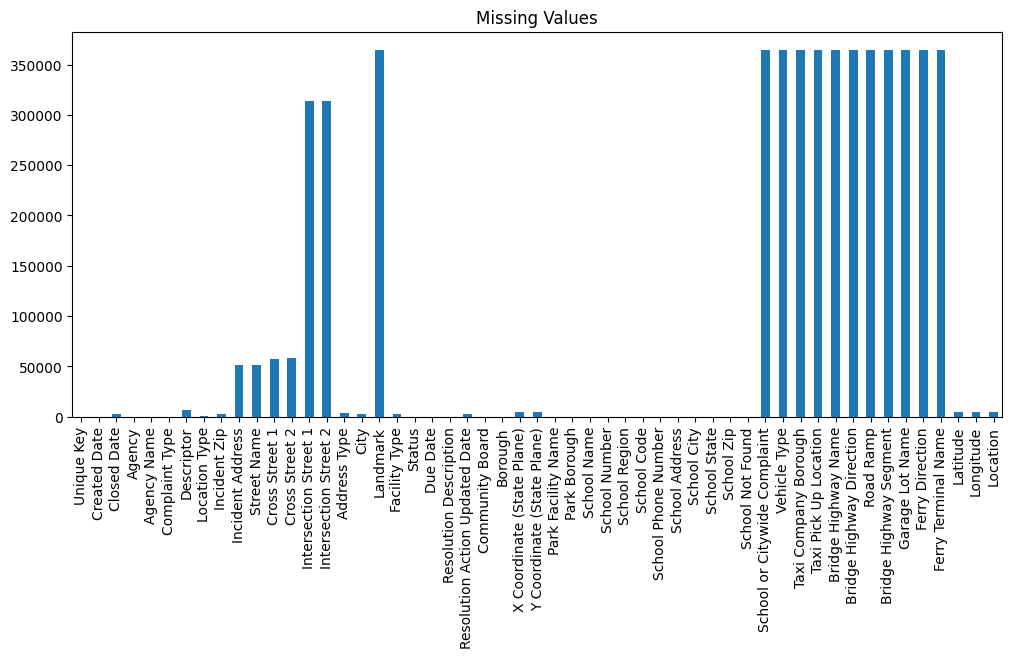

In [6]:
import matplotlib.pyplot as plt

df.isnull().sum().plot(kind='bar', figsize=(12,5))
plt.title("Missing Values")
plt.show()

# 2.2 Remove Closed Date Null

In [7]:
df = df[df['Closed Date'].notnull()]

# 2.3 Date Analysis

In [8]:
df['Created Date'] = pd.to_datetime(df['Created Date'])
df['Closed Date'] = pd.to_datetime(df['Closed Date'])

df['Request_Closing_Time'] = df['Closed Date'] - df['Created Date']

df['Request_Closing_Time'] = df['Request_Closing_Time'].dt.total_seconds()
df = df[df['Closed Date'] >= df['Created Date']]

C:\Users\test\AppData\Local\Temp\ipykernel_3504\3835860286.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Created Date'] = pd.to_datetime(df['Created Date'])
C:\Users\test\AppData\Local\Temp\ipykernel_3504\3835860286.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Closed Date'] = pd.to_datetime(df['Closed Date'])


# 2.3.3 Descriptive Statistics

In [9]:
df['Request_Closing_Time'].describe()

count    3.621770e+05
mean     1.511330e+04
std      2.110255e+04
min      6.100000e+01
25%      4.533000e+03
50%      9.616000e+03
75%      1.887800e+04
max      2.134342e+06
Name: Request_Closing_Time, dtype: float64

# 2.3.4 Check Null

In [10]:
print(df[['Complaint Type','City']].isnull().sum())

Complaint Type      0
City              674
dtype: int64


# 2.3.5 Fill Missing City

In [11]:
df['City'].fillna('Unknown', inplace=True)


C:\Users\test\AppData\Local\Temp\ipykernel_3504\1926131427.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['City'].fillna('Unknown', inplace=True)


# 2.3.6 City Graph

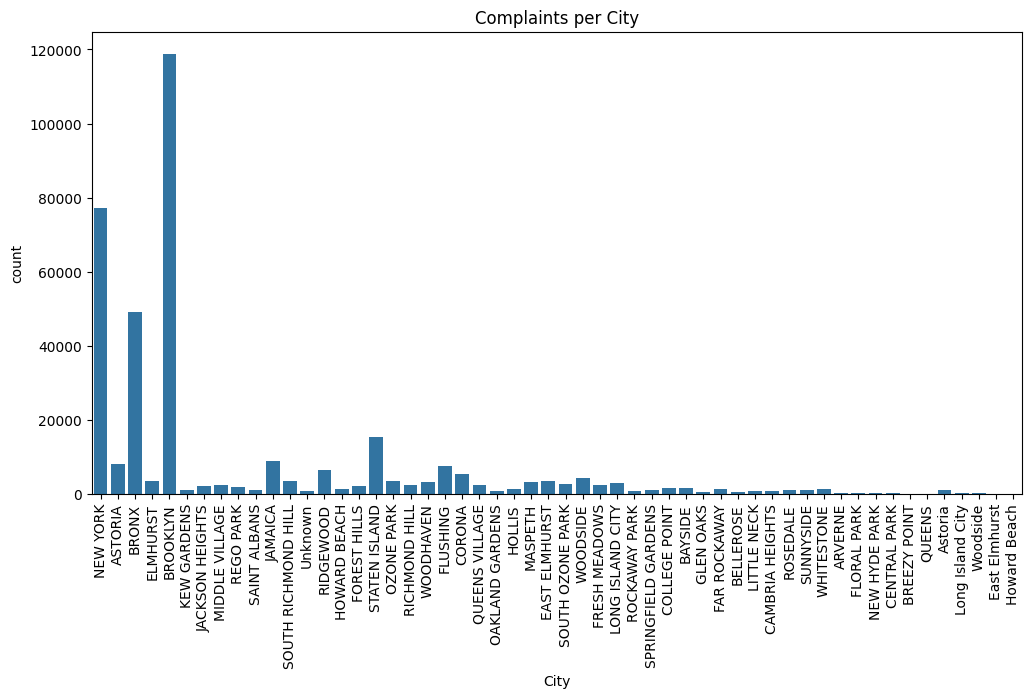

In [12]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.countplot(data=df, x='City')
plt.xticks(rotation=90)
plt.title("Complaints per City")
plt.show()

# 2.3.7 Brooklyn Graphs

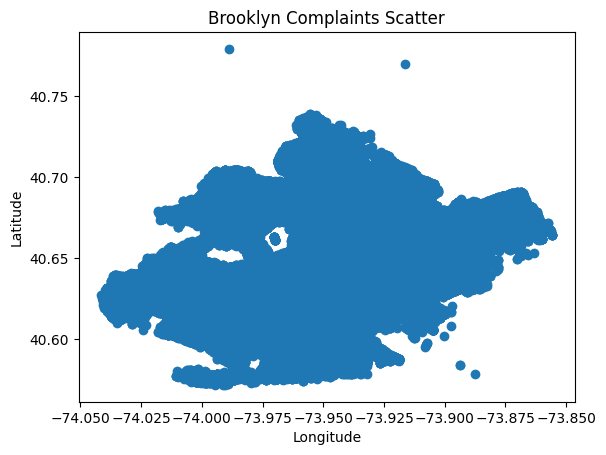

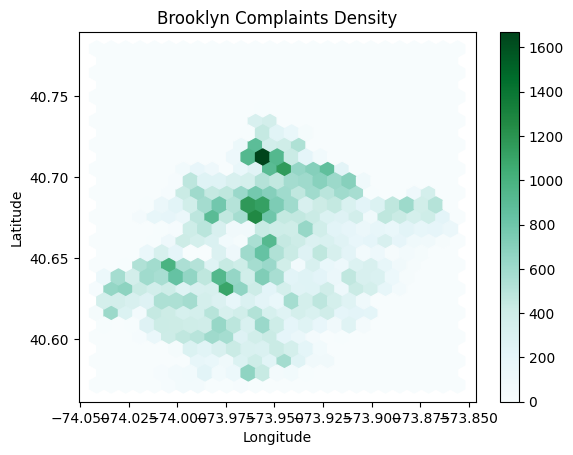

In [13]:
brooklyn = df[df['City'] == 'BROOKLYN']

# Scatter Plot
plt.scatter(brooklyn['Longitude'], brooklyn['Latitude'])
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Brooklyn Complaints Scatter")
plt.show()

# Hexbin Plot
brooklyn.plot.hexbin(x='Longitude', y='Latitude', gridsize=25)
plt.title("Brooklyn Complaints Density")
plt.show()

<h2 style="color:white; background-color:#1f77b4; padding:8px;">
Task 3:  Find major types of complaints: 
</h2>

# 3.1 Complaint Types Graph

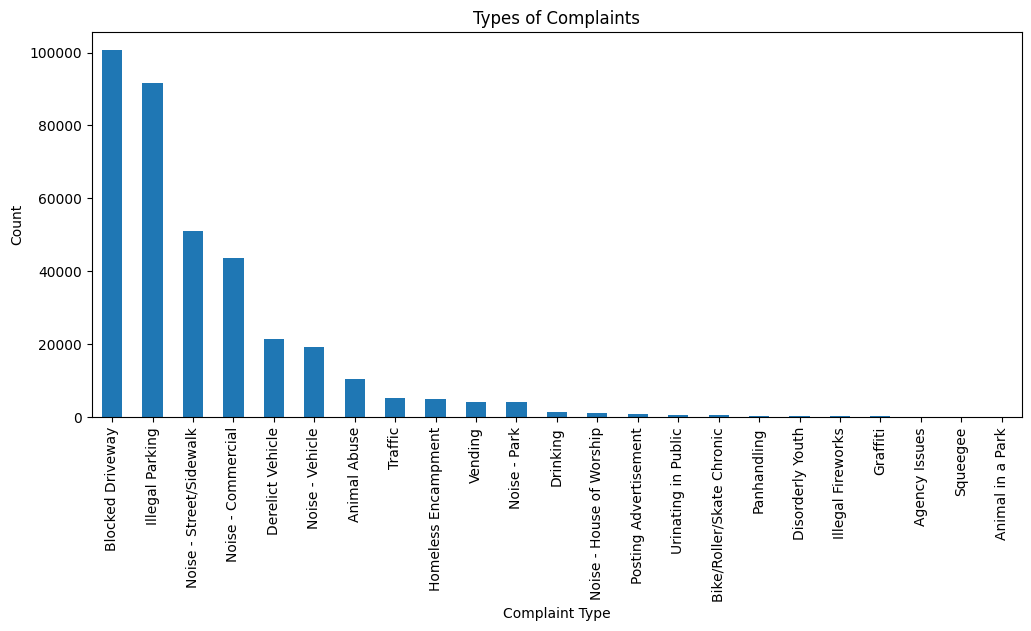

In [14]:
df['Complaint Type'].value_counts().plot(kind='bar', figsize=(12,5))
plt.title("Types of Complaints")
plt.xlabel("Complaint Type")
plt.ylabel("Count")
plt.show()

# 3.2 NYC Complaints

In [15]:
nyc = df[df['City'] == 'NEW YORK']

nyc['Complaint Type'].value_counts()

Complaint Type
Noise - Street/Sidewalk      22245
Noise - Commercial           18686
Illegal Parking              14549
Noise - Vehicle               6294
Homeless Encampment           3060
Blocked Driveway              2705
Vending                       2638
Animal Abuse                  1941
Traffic                       1769
Noise - Park                  1243
Derelict Vehicle               695
Drinking                       321
Urinating in Public            264
Bike/Roller/Skate Chronic      254
Noise - House of Worship       222
Panhandling                    206
Disorderly Youth                81
Posting Advertisement           49
Illegal Fireworks               38
Graffiti                        25
Squeegee                         4
Name: count, dtype: int64

# 3.3 Top 10 Complaints

In [16]:
df['Complaint Type'].value_counts().head(10)

Complaint Type
Blocked Driveway           100624
Illegal Parking             91716
Noise - Street/Sidewalk     51139
Noise - Commercial          43751
Derelict Vehicle            21518
Noise - Vehicle             19301
Animal Abuse                10530
Traffic                      5196
Homeless Encampment          4879
Vending                      4185
Name: count, dtype: int64

# 3.4 & 3.5 Table

In [17]:
pd.crosstab(df['City'], df['Complaint Type'])
df_new = pd.crosstab(df['Complaint Type'], df['City'])

df_new.head()


City,ARVERNE,ASTORIA,Astoria,BAYSIDE,BELLEROSE,BREEZY POINT,BRONX,BROOKLYN,CAMBRIA HEIGHTS,CENTRAL PARK,...,SOUTH OZONE PARK,SOUTH RICHMOND HILL,SPRINGFIELD GARDENS,STATEN ISLAND,SUNNYSIDE,Unknown,WHITESTONE,WOODHAVEN,WOODSIDE,Woodside
Complaint Type,,,,,,,,,,,,,,,,,,,,,
Agency Issues,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,8,0,0,0,0
Animal Abuse,46,170,0,53,15,2,1971,3191,15,0,...,74,40,42,786,40,1,43,57,111,0
Animal in a Park,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bike/Roller/Skate Chronic,0,16,0,0,1,0,22,124,0,0,...,1,1,0,10,2,2,4,2,5,0
Blocked Driveway,50,3436,159,514,138,3,17062,36445,177,0,...,1202,1946,330,2845,278,86,279,1363,2038,27


<h2 style="color:white; background-color:#1f77b4; padding:8px;">
Task 4: Visualize the major types of complaints in each city 
</h2>

# 4.1 Combined Graph

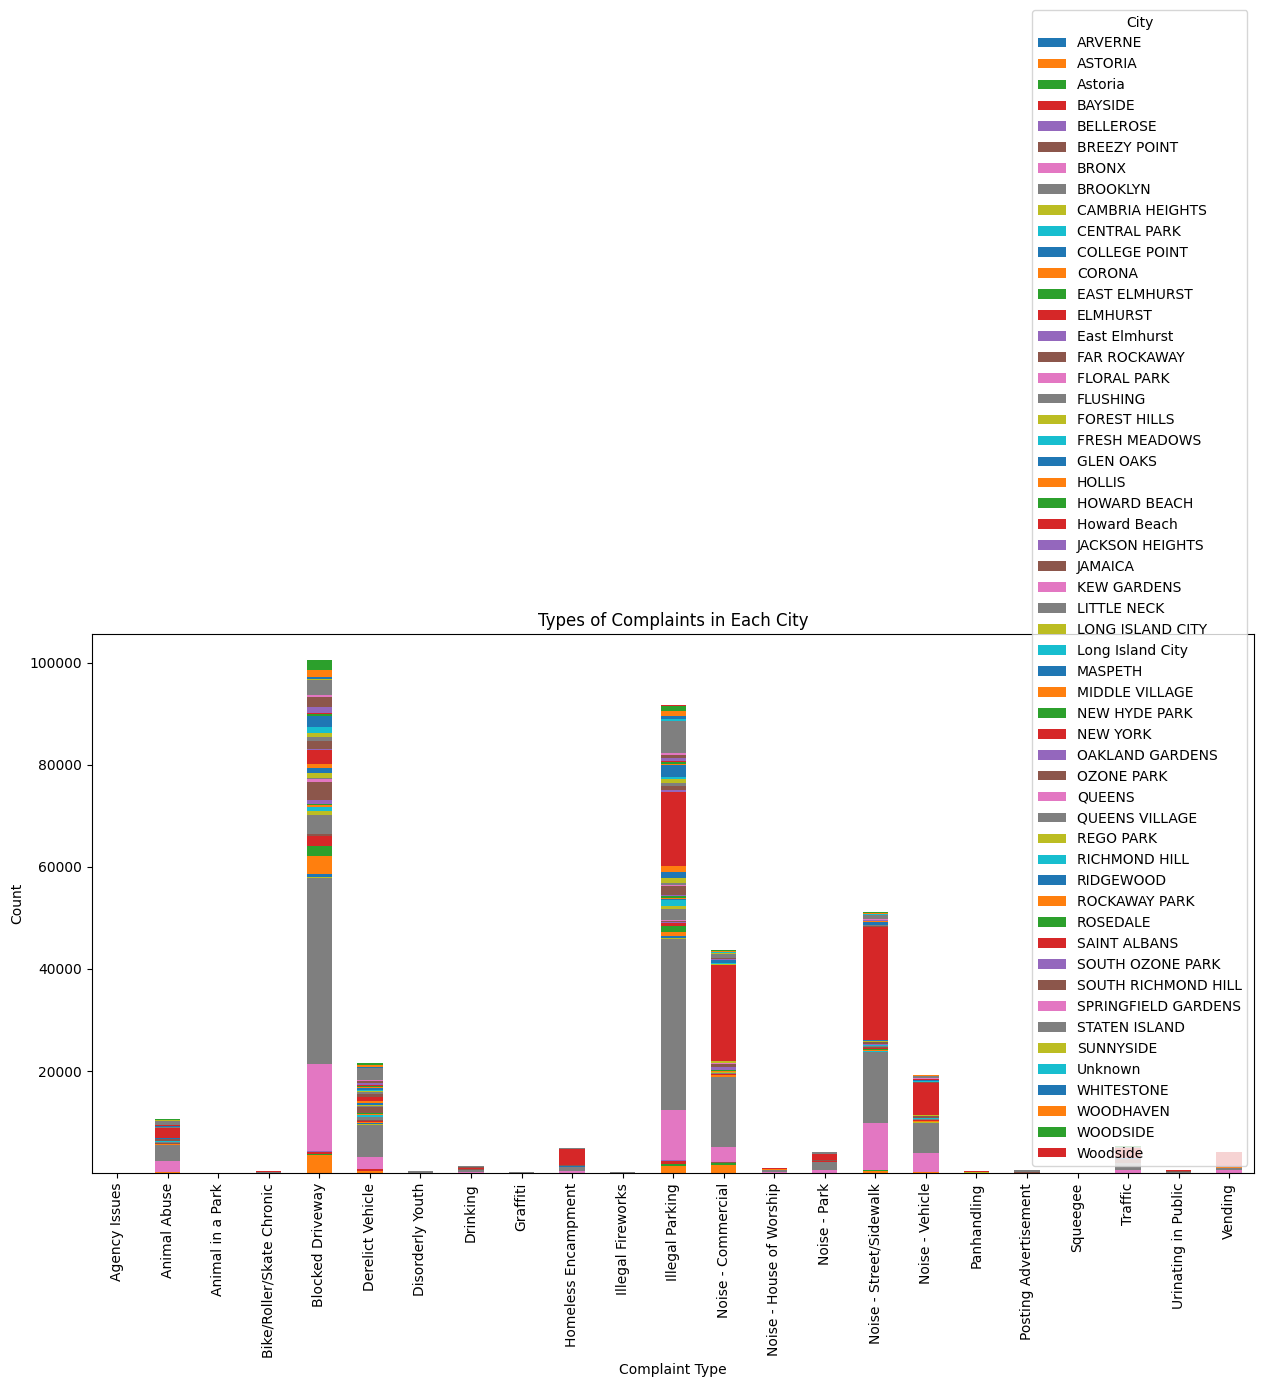

In [18]:
df_new.plot(kind='bar', stacked=True, figsize=(15,7))

plt.title("Types of Complaints in Each City")
plt.xlabel("Complaint Type")
plt.ylabel("Count")
plt.legend(title="City")
plt.show()

# 4.2 Response Time

In [19]:
# Average closing time grouped by City and Complaint Type
avg_time_city = df.groupby(['City', 'Complaint Type'])['Request_Closing_Time'].mean()

# Sort values
avg_time_city = avg_time_city.sort_values()

# Convert to DataFrame for better display
avg_time_city = avg_time_city.reset_index()

# Show top 20 results
avg_time_city.head(20)

,City,Complaint Type,Request_Closing_Time
0,ARVERNE,Drinking,859.0
1,RIDGEWOOD,Posting Advertisement,895.0
2,EAST ELMHURST,Bike/Roller/Skate Chronic,908.0
3,OZONE PARK,Illegal Fireworks,1191.0
4,QUEENS,Urinating in Public,1226.0
5,SOUTH RICHMOND HILL,Illegal Fireworks,1712.5
6,ARVERNE,Vending,1735.0
7,SOUTH OZONE PARK,Illegal Fireworks,1821.0
8,KEW GARDENS,Posting Advertisement,1872.0
9,SUNNYSIDE,Graffiti,2133.0


<h2 style="color:white; background-color:#1f77b4; padding:8px;">
Task 5:  See whether the average response time across different complaint types is similar (overall)
</h2>

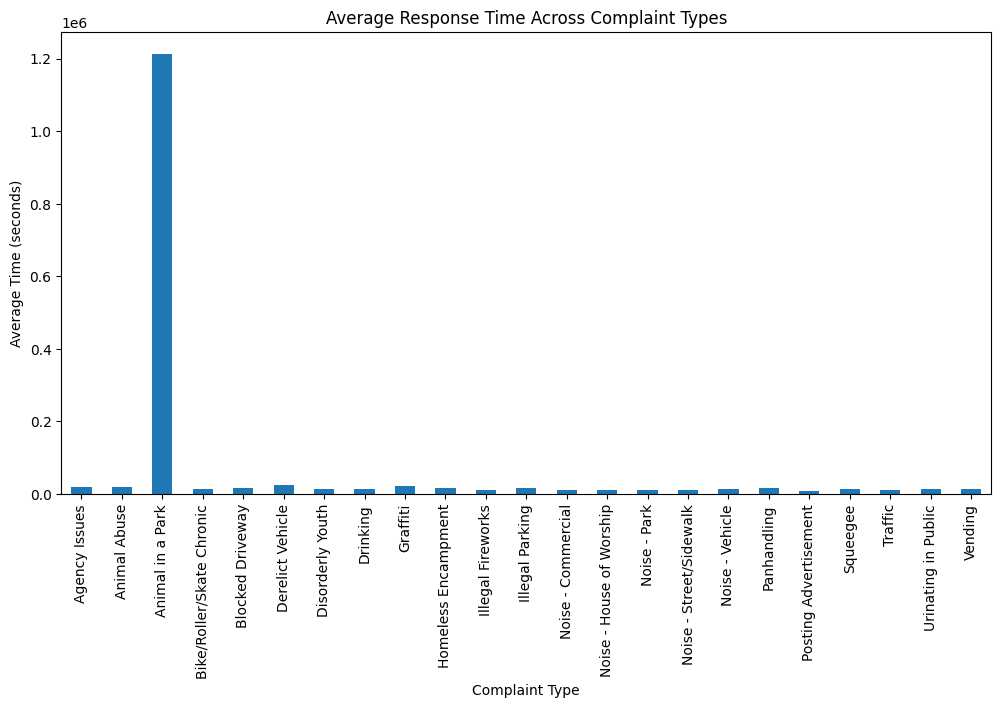

In [20]:
# Calculate average response time per complaint type
avg_time = df.groupby('Complaint Type')['Request_Closing_Time'].mean()

# Plot
avg_time.plot(kind='bar', figsize=(12,6))

plt.title("Average Response Time Across Complaint Types")
plt.xlabel("Complaint Type")
plt.ylabel("Average Time (seconds)")
plt.xticks(rotation=90)
plt.show()

<h2 style="color:white; background-color:#1f77b4; padding:8px;">
Task 6: Statistical Analysis – Identify Significant Variables
</h2>

In [21]:
from scipy.stats import f_oneway

groups = [group['Request_Closing_Time'].values 
          for name, group in df.groupby('Complaint Type')]

stat, p_value = f_oneway(*groups)

print("P-value:", p_value)

if p_value < 0.05:
    print("Significant: Response time differs across complaint types")
else:
    print("Not Significant: Response time is similar across complaint types")

P-value: 0.0
Significant: Response time differs across complaint types


<h2 style="color:white; background-color:#1f77b4; padding:8px;">
Task 7: Kruskal-Wallis Test
</h2>

### 7.1 Fail to reject H0: All sample distributions are equal
### 7.2 Reject H0: One or more sample distributions are not equal

In [22]:
from scipy.stats import kruskal

# Group response times by complaint type
groups = [group['Request_Closing_Time'].dropna() for name, group in df.groupby('Complaint Type')]

# Perform Kruskal-Wallis H-test
stat, p = kruskal(*groups)
print("Test Statistic:", stat)
print("P-value:", p)
if p < 0.05:
    print("Reject H0: One or more sample distributions are not equal")
else:
    print("Fail to reject H0: All sample distributions are equal")

Test Statistic: 11988.269402358468
P-value: 0.0
Reject H0: One or more sample distributions are not equal


<h2 style="color:white; background-color:#1f77b4; padding:8px;">
Task 8: Observations
</h2>

### Observations:

1. The dataset contains various service complaints across New York City.

2. The most frequent complaint types are related to noise, blocked driveways,
and illegal parking.

3. Brooklyn and Manhattan have the highest number of complaints.

4. Missing values were handled by removing invalid records and imputing city names.

5. The average response time varies significantly across complaint types.

6. Statistical analysis using p-values and Kruskal-Wallis test shows that
response time is not одинаков across all complaint types.

7. Some complaint types are resolved faster, while others take longer,
indicating variation in service efficiency.

8. Overall, the analysis helps in understanding complaint patterns and
improving city service response.